# Linear heat conduction problem with same material, with full order and reduced order simulations.

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib
# -----------------------------------------------------------------------------
# Project-root auto-detection script
# Ensures the top-level directory (containing 'src/' and 'tests/')
# is on Python's import path, allowing modules to be imported consistently
# regardless of the current working directory (e.g., in notebooks).
# -----------------------------------------------------------------------------

# 1) Start from the current working directory (or notebook location)
notebook_path = Path().resolve()
linear_dir = notebook_path.parent     # .../linear
# 2) Traverse upward through parent directories to find the project root
for parent in notebook_path.parents:
    # Check for indicators of the project's root structure
    if (parent / "src").exists() and (parent / "tests").exists():
        project_root = parent
        break
else:
    # If loop completes without break, no valid root was found
    raise RuntimeError(
        "Could not find project root containing 'src' and 'tests'"
    )

# 3) Prepend the detected root to sys.path to prioritize local modules
sys.path.insert(0, str(project_root))

if str(linear_dir) not in sys.path:
    sys.path.insert(0, str(linear_dir))
    
# 4) Confirm successful addition (optional print for debugging)
print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/syedabidi/Documents/GitHub/scikit-rom


### Standard Imports

In [2]:
#Standard Imports and class import
from src.skrom.utils.imports import *
from src.skrom.rom.rom_utils import *
from src.skrom.utils.reduced_basis.svd import svd_mode_selector
from src.skrom.rom.rom_error_est import *
from src.skrom.utils.visualization.color_palette import set_color_palette
import src.skrom.problem_classes.master_class_static as master
importlib.import_module("problem_1.problem_def")   # this runs @register_problem

<module 'problem_1.problem_def' from '/Users/syedabidi/Documents/GitHub/scikit-rom/examples/heat_transfer/static/linear/problem_1/problem_def.py'>

### Plot Properties

In [3]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();

## Full Order Simulation

In [4]:

# Control flag for expensive simulation generation
# Set to False to skip computationally intensive simulation and use existing data
# Set to True when you need to regenerate simulation data (e.g., parameter changes)
generate = True

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the linear heat conduction simulation
    sim =  master.fom_simulation()
    #Run the simulation
    sim.run_simulation()


Snap 1/64 params=[  3.97085022 702.17184536]
Snap 2/64 params=[-5.26216708e-01 -8.03974727e+02]
Snap 3/64 params=[ -2.64860117 303.88297886]
Snap 4/64 params=[   1.84456213 -202.56850123]
Snap 5/64 params=[  0.12764315 121.4639172 ]
Snap 6/64 params=[  -3.36942626 -379.03615832]
Snap 7/64 params=[ -1.49289148 879.18929569]
Snap 8/64 params=[   2.00026906 -621.12889625]
Snap 9/64 params=[  2.88467383 490.92518352]
Snap 10/64 params=[ -1.61045047 -14.61057551]
Snap 11/64 params=[ -3.73820317 514.27525282]
Snap 12/64 params=[ 7.60824278e-01 -9.91078027e+02]
Snap 13/64 params=[  1.22798733 818.184793  ]
Snap 14/64 params=[  -2.26713372 -685.12428552]
Snap 15/64 params=[ -0.39401977 185.52028202]
Snap 16/64 params=[   3.10501063 -318.09239276]
Snap 17/64 params=[  3.47045281 241.8720983 ]
Snap 18/64 params=[-2.46596858e-02 -2.65557613e+02]
Snap 19/64 params=[ -2.15204635 765.16119577]
Snap 20/64 params=[   1.34696977 -741.96408503]
Snap 21/64 params=[  0.6261446 567.1786461]
Snap 22/64 para

### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)



[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/examples/heat_transfer/static/linear/problem_1/ROM_data


## Data Generation

### Generate training solution dataset

In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


64


### Training Solution Snapshots

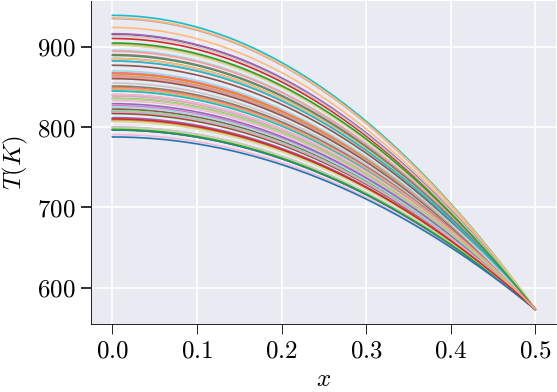

In [7]:
# Plot the computed temperature distribution
# Create a figure with specified dimensions (5x3.5 inches) for compact visualization
plt.figure(figsize=(5, 3.5))

# Extract spatial coordinates from the mesh data
# The mesh is stored as an object in sim_data, accessed via .item() to get the actual mesh
# mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
mesh_domain = sim_data['mesh'].item().p[0]

# Plot temperature profiles for all parameter combinations
# Loop through all non-linear solutions (each row is a complete temperature field)
for j in range(len(LS)):
    # Plot each temperature distribution as a line
    # x-axis: spatial coordinates from the mesh
    # y-axis: temperature values at each spatial location
    # '-' specifies solid line style, markersize affects any markers
    plt.plot(mesh_domain, LS[j], '-', markersize=2)

# Set axis labels with proper mathematical notation
plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
plt.ylabel("$T (K)$")    # Temperature in Kelvin (LaTeX formatting)

# Display the plot
plt.show()

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Distribution of training parameters

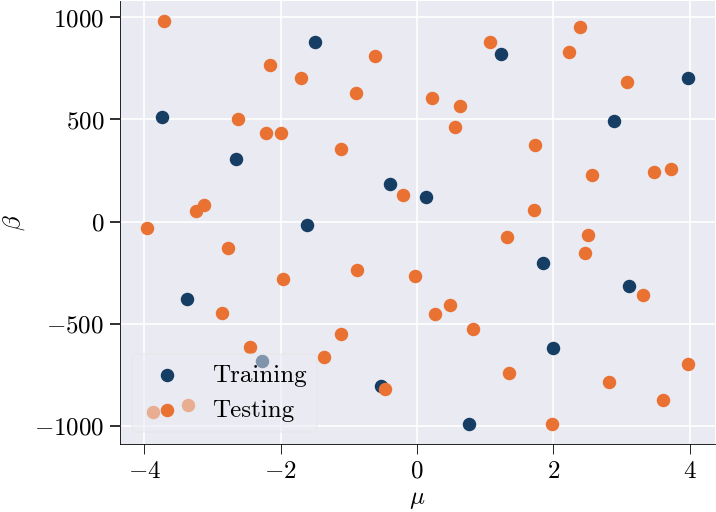

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 2


Text(0.5, 0, 'POD modes ($k$)')

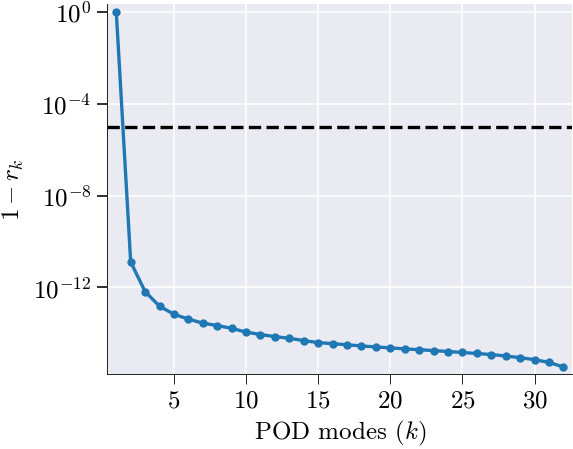

In [10]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(LS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-5,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors


# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

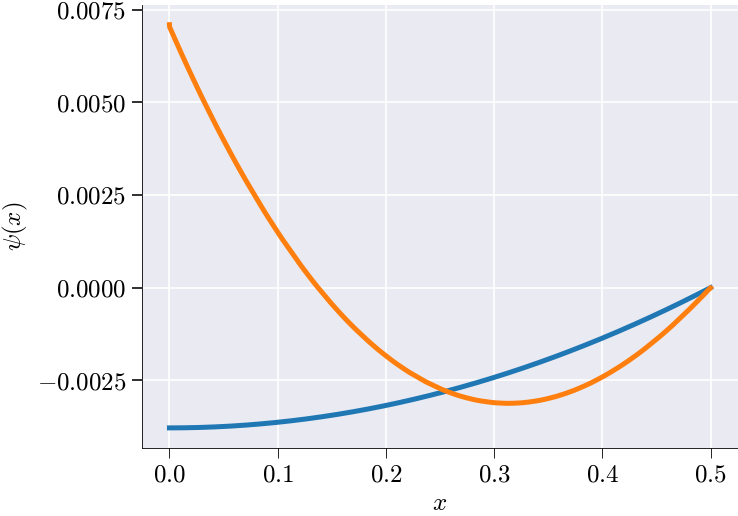

In [11]:
# Create figure and axis for POD modes visualization
fig, ax = plt.subplots()


# Plot all selected POD spatial modes
for i in range(n_sel):
    # Plot each POD mode as a function of spatial coordinate
    # x-axis: spatial locations (DOF coordinates)
    # y-axis: POD mode amplitude at each spatial location
    # lw=3: Use thick lines for better visibility of mode shapes
    plt.plot(mesh_domain, V_sel[:, i], lw=3)

# Set axis labels with mathematical notation
ax.set_xlabel('$x$')        # Spatial coordinate
ax.set_ylabel('$\\psi(x)$')  # POD mode amplitude (basis function value)

# Control the number of y-axis ticks for cleaner appearance
# nbins=5: Limit to approximately 5 major tick marks on y-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Display the plot
plt.show()

## ROM Simulation

In [12]:
# Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
rom = master.rom_simulation(V_sel=V_sel)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/examples/heat_transfer/static/linear/problem_1/ROM_data


In [13]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
rom.run_rom_simulation();

Snap 1/64 params=[ -0.20963277 130.75588271]
Snap 2/64 params=[   2.81943309 -786.55516542]
Snap 3/64 params=[2.24175505e-01 6.07139824e+02]
Snap 4/64 params=[  -2.86352082 -450.42572543]
Snap 5/64 params=[ -3.71364783 983.63880068]
Snap 6/64 params=[  1.32369592 -77.84050517]
Snap 7/64 params=[  3.72840031 257.25489296]
Snap 8/64 params=[  -1.36749761 -663.96991909]
Snap 9/64 params=[ -1.70637654 703.98105867]
Snap 10/64 params=[   3.315326   -359.77936536]
Snap 11/64 params=[ 1.71919211 55.36925793]
Snap 12/64 params=[  -3.36109702 -898.65424298]
Snap 13/64 params=[ -2.21800174 431.86839484]
Snap 14/64 params=[   0.82670342 -526.0691084 ]
Snap 15/64 params=[  2.23057704 830.48016205]
Snap 16/64 params=[  -0.87272997 -237.19425686]
Snap 17/64 params=[-6.11884236e-01  8.12472606e+02]
Snap 18/64 params=[   2.47180665 -155.7110697 ]
Snap 19/64 params=[  0.56417269 460.60944349]
Snap 20/64 params=[  -2.45315152 -616.33458547]
Snap 21/64 params=[-3.12401679 83.14153366]
Snap 22/64 params=[

In [14]:
#Assign values for the statistics
LS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up[1:]
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 9.1739e-06
Relative L2 Error:        5.8571e-12
L∞ Error:                 2.0062e-08
Relative L∞ Error:        2.1360e-11
RMSE:                     4.4794e-09
MAE:                      1.9832e-09

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -1.0562e-10
95th Percentile Error:    1.2955e-08

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.9366e-12
Max Rel L2 Error over time/parameter: 1.3644e-11
Min Rel L2 Error over time/parameter: 2.5587e-13
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

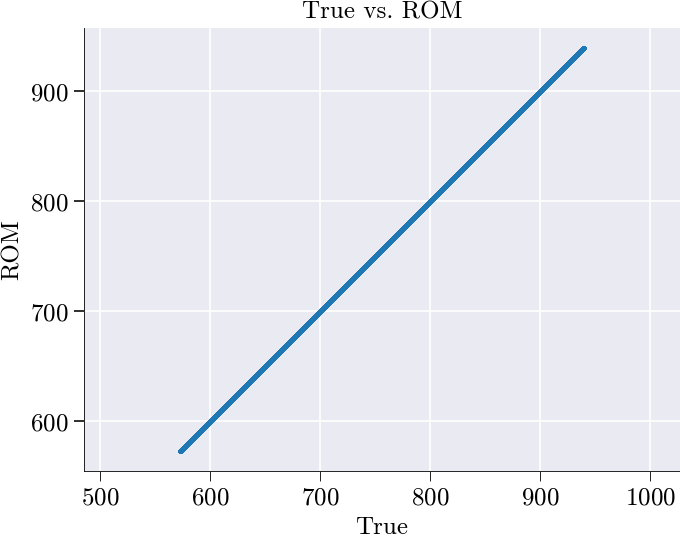

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


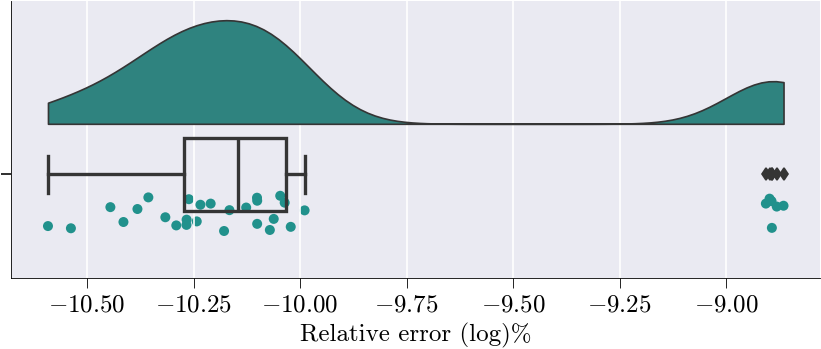

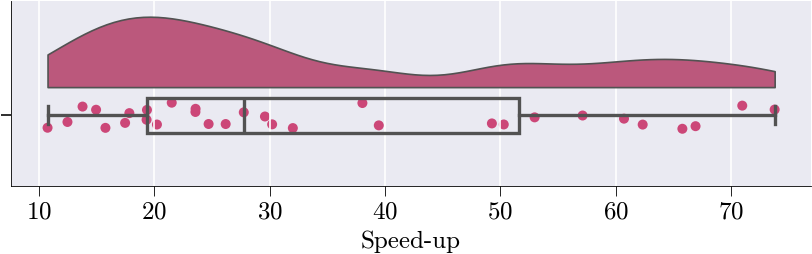

In [15]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    LS_test,                   # full-order (true) solution snapshots
    LS_rom,              # hyper-ROM-generated solution snapshots
    ROM_relative_error,   # precomputed relative error of the hyper-ROM
    ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)
